In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("/content/digital_marketing_dataset_30k.csv")

df.head()

,date,year,month,month_name,week,day_of_week,post_hour,season,is_holiday,is_holiday (text),...,ad_id,ad_name,spend,impressions,reach,frequency,clicks,conversions,revenue,video_views
0,08/04/2023,2023,4,Apr,14,Sat,7,Spring,0,No,...,AD8747890,In-Feed_V1,871.17,172632,77865,2.22,1440,0,0.00,54610
1,28/04/2025,2025,4,Apr,18,Mon,12,Spring,0,No,...,AD2884130,Feed_V9,362.55,30111,15083,2.00,283,0,0.00,8086
2,18/12/2024,2024,12,Dec,51,Wed,10,Winter,0,No,...,AD5656772,Display_V7,362.09,111125,56453,1.97,1238,7,671.74,0
3,26/04/2024,2024,4,Apr,17,Fri,20,Spring,0,No,...,AD3443678,Stories_V2,54.45,10844,4736,2.29,83,0,0.00,0
4,19/04/2024,2024,4,Apr,16,Fri,22,Spring,0,No,...,AD8461978,Reels_V8,56.18,6423,3010,2.13,59,0,0.00,1160


In [4]:
df.columns

Index(['date', 'year', 'month', 'month_name', 'week', 'day_of_week',
       'post_hour', 'season', 'is_holiday', 'is_holiday (text)', 'is_weekend',
       'is_weekend (text)', 'country', 'market_tier', 'account',
       'account_type', 'platform', 'placement', 'funnel_stage', 'objective',
       'theme', 'campaign_id', 'campaign_name', 'ad_group_id', 'ad_group_name',
       'ad_id', 'ad_name', 'spend', 'impressions', 'reach', 'frequency',
       'clicks', 'conversions', 'revenue', 'video_views'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               30000 non-null  object 
 1   year               30000 non-null  int64  
 2   month              30000 non-null  int64  
 3   month_name         30000 non-null  object 
 4   week               30000 non-null  int64  
 5   day_of_week        30000 non-null  object 
 6   post_hour          30000 non-null  int64  
 7   season             30000 non-null  object 
 8   is_holiday         30000 non-null  int64  
 9   is_holiday (text)  30000 non-null  object 
 10  is_weekend         30000 non-null  int64  
 11  is_weekend (text)  30000 non-null  object 
 12  country            30000 non-null  object 
 13  market_tier        30000 non-null  object 
 14  account            30000 non-null  object 
 15  account_type       30000 non-null  object 
 16  platform           300

In [6]:
df.isnull().sum()

,0
date,0
year,0
month,0
month_name,0
week,0
day_of_week,0
post_hour,0
season,0
is_holiday,0
is_holiday (text),0


In [7]:
df = df.dropna()

In [8]:
df = df.drop_duplicates()

In [11]:
df['platform'].unique()

array(['TikTok', 'Meta', 'Google Display', 'Snapchat', 'LinkedIn',
       'Google Search'], dtype=object)

In [12]:
df[['impressions','clicks','conversions']].sum()

,0
impressions,1701763447
clicks,25617140
conversions,322798


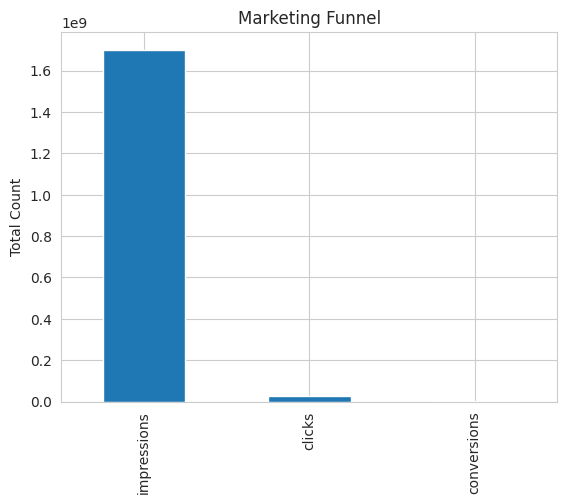

In [13]:
#Funnel Chart
totals = df[['impressions','clicks','conversions']].sum()

plt.figure()
totals.plot(kind='bar')
plt.title("Marketing Funnel")
plt.ylabel("Total Count")
plt.show()

In [14]:
df['ROI'] = (df['revenue'] - df['spend']) / df['spend']

In [15]:
roi_platform = df.groupby('platform')['ROI'].mean().sort_values(ascending=False)

roi_platform

,ROI
platform,
Google Search,2.849727
Meta,-0.351613
TikTok,-0.493634
Snapchat,-0.515172
Google Display,-0.718510
LinkedIn,-0.908153


In [19]:
df.groupby('platform')['revenue'].sum().sort_values(ascending=False)

,revenue
platform,
Google Search,10362175.17
Meta,1640105.78
TikTok,993860.85
Snapchat,669736.81
Google Display,328505.21
LinkedIn,276970.44


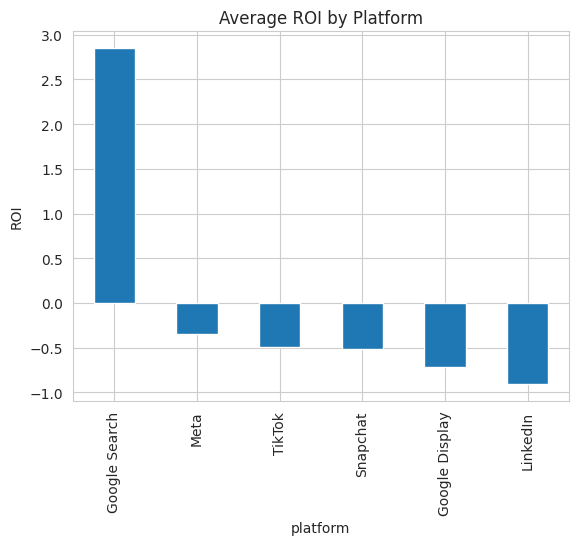

In [16]:
#ROI by Platform Chart
plt.figure()
roi_platform.plot(kind='bar')
plt.title("Average ROI by Platform")
plt.ylabel("ROI")
plt.show()

In [17]:
spend_revenue = df.groupby('platform')[['spend','revenue']].sum()

spend_revenue

,spend,revenue
platform,,
Google Display,1157077.08,328505.21
Google Search,2744251.20,10362175.17
LinkedIn,2556360.66,276970.44
Meta,2636602.54,1640105.78
Snapchat,1450865.95,669736.81
TikTok,2091251.63,993860.85


<Figure size 640x480 with 0 Axes>

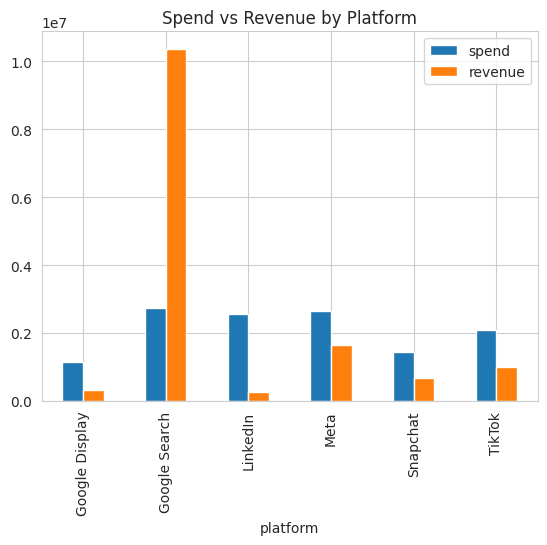

In [18]:
#Total Spend vs Revenue by Platform
plt.figure()
spend_revenue.plot(kind='bar')
plt.title("Spend vs Revenue by Platform")
plt.show()